**Project Overview**

This project analyzes BMW used car listings to uncover pricing patterns, demand by model, and key factors influencing resale value.  
The goal is to provide actionable insights for dealerships and buyers.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')
from bokeh.plotting import figure, show, output_file, save
from bokeh.models import ColumnDataSource, HoverTool, NumeralTickFormatter
from bokeh.transform import factor_cmap
from bokeh.palettes import Viridis256

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
df=pd.read_csv('/content/bmw.csv')

In [ ]:
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0
...,...,...,...,...,...,...,...,...,...
10776,X3,2016,19000,Automatic,40818,Diesel,150,54.3,2.0
10777,5 Series,2016,14600,Automatic,42947,Diesel,125,60.1,2.0
10778,3 Series,2017,13100,Manual,25468,Petrol,200,42.8,2.0
10779,1 Series,2014,9930,Automatic,45000,Diesel,30,64.2,2.0


In [ ]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0


In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
df['model'] = df['model'].str.strip()

In [ ]:
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0
...,...,...,...,...,...,...,...,...,...
10776,X3,2016,19000,Automatic,40818,Diesel,150,54.3,2.0
10777,5 Series,2016,14600,Automatic,42947,Diesel,125,60.1,2.0
10778,3 Series,2017,13100,Manual,25468,Petrol,200,42.8,2.0
10779,1 Series,2014,9930,Automatic,45000,Diesel,30,64.2,2.0


In [ ]:
duplicate_values=df[df.duplicated()]
duplicate_values

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
174,X4,2019,33998,Semi-Auto,7272,Diesel,150,42.8,2.0
393,X1,2018,16995,Semi-Auto,17276,Petrol,150,46.3,1.5
709,2 Series,2014,11999,Manual,31289,Diesel,30,62.8,2.0
957,1 Series,2019,21898,Manual,4100,Petrol,150,41.5,1.5
1173,1 Series,2017,20995,Semi-Auto,31544,Petrol,145,39.8,3.0
...,...,...,...,...,...,...,...,...,...
7808,5 Series,2019,31550,Automatic,1550,Hybrid,140,156.9,2.0
9096,M4,2020,45488,Automatic,10,Petrol,150,34.0,3.0
9797,4 Series,2019,25449,Automatic,6890,Diesel,145,65.7,2.0
9940,M3,2009,16950,Manual,65000,Petrol,580,21.9,4.0


In [ ]:
duplicates = df.duplicated().sum()

In [ ]:
duplicates

np.int64(117)

In [ ]:
df = df.drop_duplicates()

In [ ]:
# Standardize column names
df.columns = df.columns.str.lower()

In [ ]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fueltype', 'tax',
       'mpg', 'enginesize'],
      dtype='object')

In [ ]:
# Check for missing values
missing_values = df.isnull().sum()

In [ ]:
missing_values

,0
model,0
year,0
price,0
transmission,0
mileage,0
fueltype,0
tax,0
mpg,0
enginesize,0


In [ ]:
df

,model,year,price,transmission,mileage,fueltype,tax,mpg,enginesize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0
...,...,...,...,...,...,...,...,...,...
10776,X3,2016,19000,Automatic,40818,Diesel,150,54.3,2.0
10777,5 Series,2016,14600,Automatic,42947,Diesel,125,60.1,2.0
10778,3 Series,2017,13100,Manual,25468,Petrol,200,42.8,2.0
10779,1 Series,2014,9930,Automatic,45000,Diesel,30,64.2,2.0


**2. DATA PREPROCESSING**

In [ ]:
# Feature Engineering - Calculate Car Age
# (Assuming current year is 2024)
df['car_age'] = 2025 - df['year']

In [ ]:
df

,model,year,price,transmission,mileage,fueltype,tax,mpg,enginesize,car_age
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0,11
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0,7
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0,9
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5,8
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0,11
...,...,...,...,...,...,...,...,...,...,...
10776,X3,2016,19000,Automatic,40818,Diesel,150,54.3,2.0,9
10777,5 Series,2016,14600,Automatic,42947,Diesel,125,60.1,2.0,9
10778,3 Series,2017,13100,Manual,25468,Petrol,200,42.8,2.0,8
10779,1 Series,2014,9930,Automatic,45000,Diesel,30,64.2,2.0,11


In [ ]:
# Log Transformation - Target Variable (Price)
# Helps normalize the distribution for better regression performance
# df['log_price'] = np.log1p(df['price'])

In [ ]:
categorical_cols = ['model', 'transmission']
for col in categorical_cols:
    df[col] = df[col].astype('category')

In [ ]:
# Convert Numeric columns to Float
# Converting to float is standard practice for scaling and modeling
numeric_cols = ['price', 'mileage', 'tax']
for col in numeric_cols:
    df[col] = df[col].astype(float)

In [ ]:
df['year'] = df['year'].astype(int)

In [ ]:
df

,model,year,price,transmission,mileage,fueltype,tax,mpg,enginesize,car_age
0,5 Series,2014,11200.0,Automatic,67068.0,Diesel,125.0,57.6,2.0,11
1,6 Series,2018,27000.0,Automatic,14827.0,Petrol,145.0,42.8,2.0,7
2,5 Series,2016,16000.0,Automatic,62794.0,Diesel,160.0,51.4,3.0,9
3,1 Series,2017,12750.0,Automatic,26676.0,Diesel,145.0,72.4,1.5,8
4,7 Series,2014,14500.0,Automatic,39554.0,Diesel,160.0,50.4,3.0,11
...,...,...,...,...,...,...,...,...,...,...
10776,X3,2016,19000.0,Automatic,40818.0,Diesel,150.0,54.3,2.0,9
10777,5 Series,2016,14600.0,Automatic,42947.0,Diesel,125.0,60.1,2.0,9
10778,3 Series,2017,13100.0,Manual,25468.0,Petrol,200.0,42.8,2.0,8
10779,1 Series,2014,9930.0,Automatic,45000.0,Diesel,30.0,64.2,2.0,11


In [ ]:
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['enginesize'] = pd.to_numeric(df['enginesize'], errors='coerce')

In [ ]:
df = df.dropna(subset=['price', 'enginesize'])

In [ ]:
print("Updated Data Types:")
print(df.dtypes)

Updated Data Types:
model           category
year               int64
price            float64
transmission    category
mileage          float64
fueltype          object
tax              float64
mpg              float64
enginesize       float64
car_age            int64
dtype: object


In [ ]:
print("Updated Data Types:")
print(df.dtypes)

Updated Data Types:
model           category
year               int64
price            float64
transmission    category
mileage          float64
fueltype          object
tax              float64
mpg              float64
enginesize       float64
car_age            int64
dtype: object


**Data Visualization**

In [ ]:
df.columns = df.columns.str.strip()
df['model'] = df['model'].str.strip()


In [ ]:

df.columns = df.columns.str.strip().str.lower()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].str.strip()

In [ ]:
numeric_cols = ['price', 'mileage', 'tax', 'mpg', 'enginesize']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df= df.dropna(subset=['price'])

In [ ]:
sns.set_theme(style="whitegrid")

In [ ]:
def add_value_labels(ax, spacing=5, format_str='{:.0f}'):
    for rect in ax.patches:
        y_value = rect.get_height()
        x_value = rect.get_x() + rect.get_width() / 2
        label = format_str.format(y_value)
        ax.annotate(label, (x_value, y_value), xytext=(0, spacing),
                    textcoords="offset points", ha='center', va='bottom', fontsize=9)

In [ ]:
df

,model,year,price,transmission,mileage,fueltype,tax,mpg,enginesize,car_age
0,5 Series,2014,11200.0,Automatic,67068.0,Diesel,125.0,57.6,2.0,11
1,6 Series,2018,27000.0,Automatic,14827.0,Petrol,145.0,42.8,2.0,7
2,5 Series,2016,16000.0,Automatic,62794.0,Diesel,160.0,51.4,3.0,9
3,1 Series,2017,12750.0,Automatic,26676.0,Diesel,145.0,72.4,1.5,8
4,7 Series,2014,14500.0,Automatic,39554.0,Diesel,160.0,50.4,3.0,11
...,...,...,...,...,...,...,...,...,...,...
10776,X3,2016,19000.0,Automatic,40818.0,Diesel,150.0,54.3,2.0,9
10777,5 Series,2016,14600.0,Automatic,42947.0,Diesel,125.0,60.1,2.0,9
10778,3 Series,2017,13100.0,Manual,25468.0,Petrol,200.0,42.8,2.0,8
10779,1 Series,2014,9930.0,Automatic,45000.0,Diesel,30.0,64.2,2.0,11


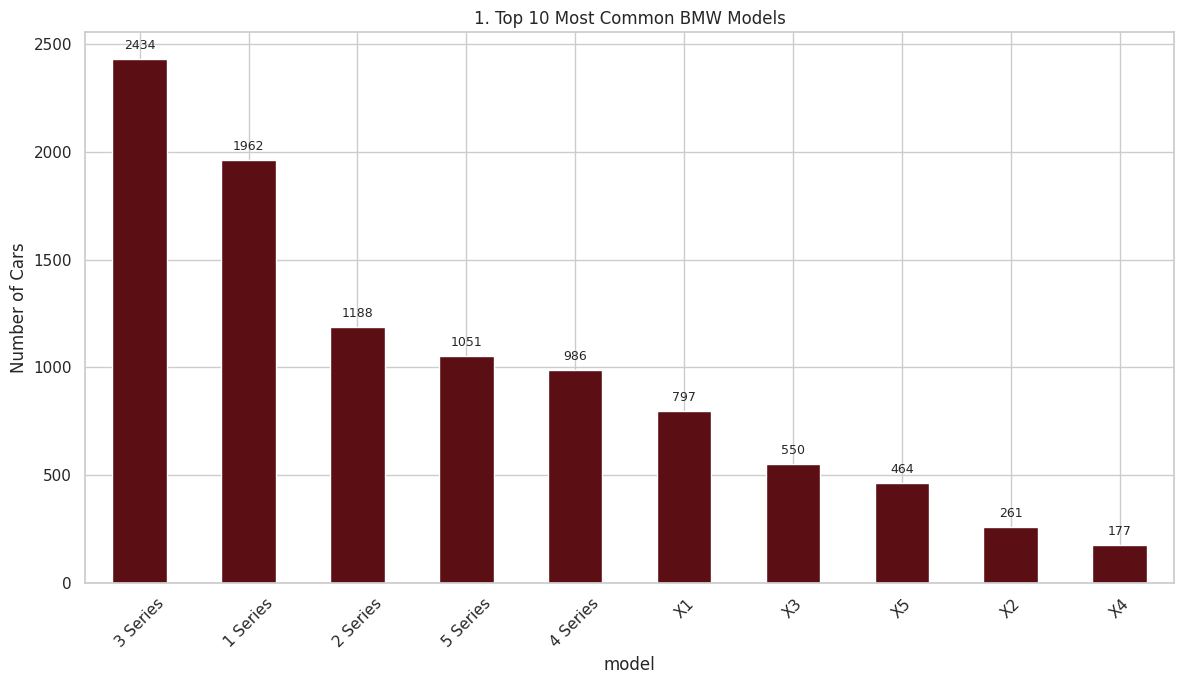

In [ ]:
# Top 10 Models (with Counts)
plt.figure(figsize=(12, 7))
ax = df['model'].value_counts().head(10).plot(kind='bar', color='#5B0E14')
add_value_labels(ax)
plt.title('1. Top 10 Most Common BMW Models')
plt.ylabel('Number of Cars')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('v1_bar_top_models.png')





2. How does mileage impact vehicle price?

In [ ]:
fig = px.scatter(df, x="mileage", y="price", color="model",
                 hover_data=['year', 'fueltype'],
                 title="Price vs Mileage")
fig.show()

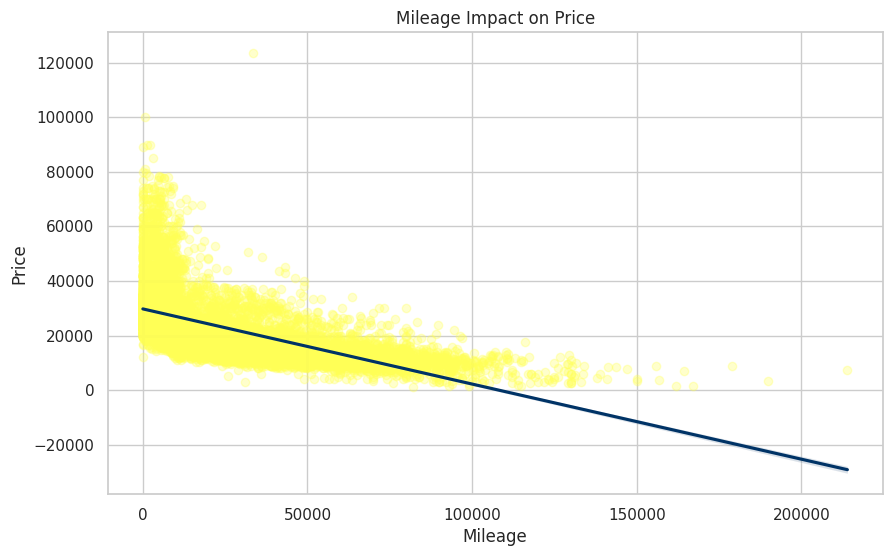

In [ ]:
df.columns = df.columns.str.strip()
df['model'] = df['model'].str.strip()
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x='mileage',
    y='price',
    color='#ffff56',
    scatter_kws={'alpha':0.3},
    line_kws={'color':'#003366'}
)

plt.title("Mileage Impact on Price")
plt.xlabel("Mileage")
plt.ylabel("Price")

plt.show()


3. Relationship between vehicle age and price

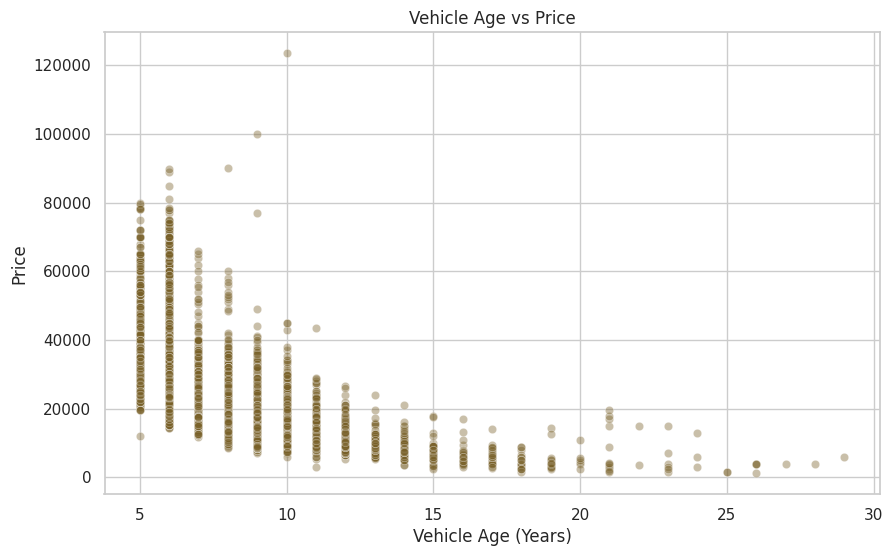

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='car_age',
    y='price',
    color='#786028',
    alpha=0.4
)

plt.title("Vehicle Age vs Price")
plt.xlabel("Vehicle Age (Years)")
plt.ylabel("Price")

plt.show()


In [ ]:
fig = px.scatter(
    df,
    x='car_age',
    y='price',
    color_discrete_sequence=['#786028'],
    opacity=0.4,
    title="Vehicle Age vs Price",
    labels={
        "car_age": "Vehicle Age (Years)",
        "price": "Price (£)"
    },
    template="plotly_white",
    hover_data=['model', 'mileage']
)


fig.show()

Which engine sizes command higher prices?

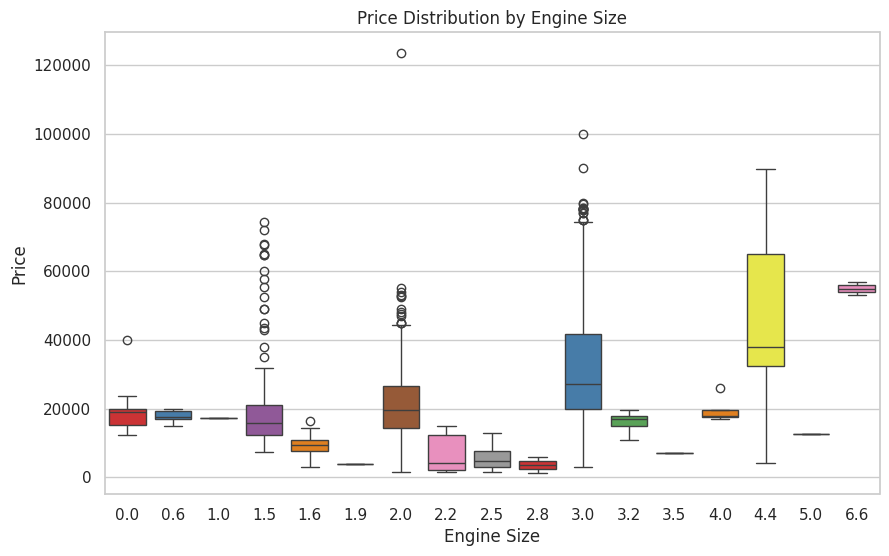

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='enginesize',
    y='price',
    palette='Set1'
)

plt.title("Price Distribution by Engine Size")
plt.xlabel("Engine Size")
plt.ylabel("Price")

plt.show()


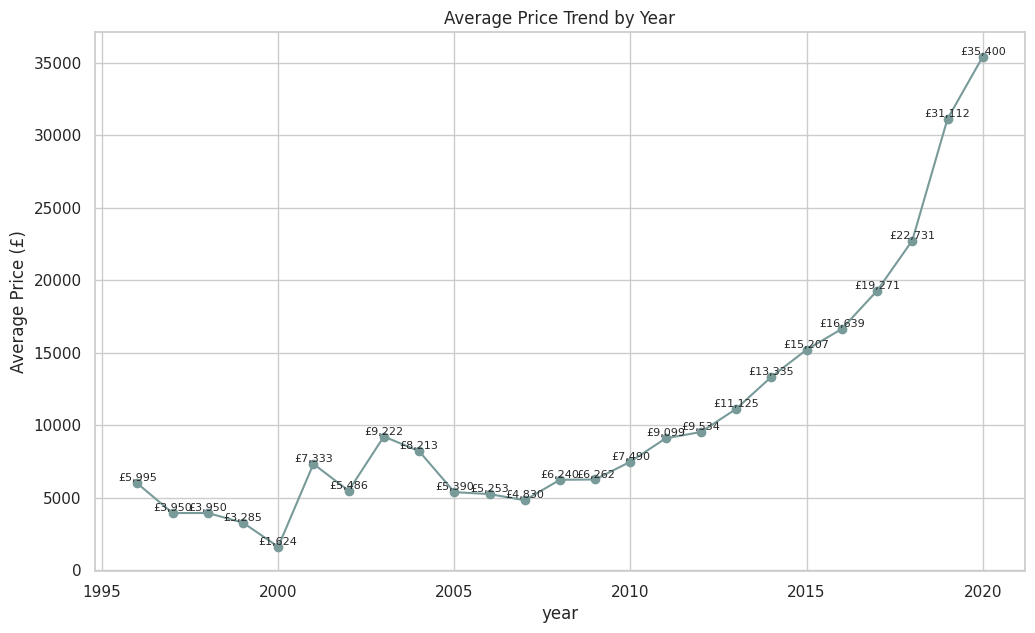

In [ ]:
# Avg Price Trend (with £ labels)
plt.figure(figsize=(12, 7))
stats = df.groupby('year')['price'].mean()
ax = stats.plot(kind='line', marker='o', color='#789A99')
for x, y in zip(stats.index, stats.values):
    plt.text(x, y, f'£{y:,.0f}', ha='center', va='bottom', fontsize=8)
plt.title('Average Price Trend by Year')
plt.ylabel('Average Price (£)')
plt.savefig('v2_line_avg_price_year.png')

What price ranges dominate the used BMW market?

In [ ]:
df.columns = df.columns.str.strip()
df['model'] = df['model'].str.strip()

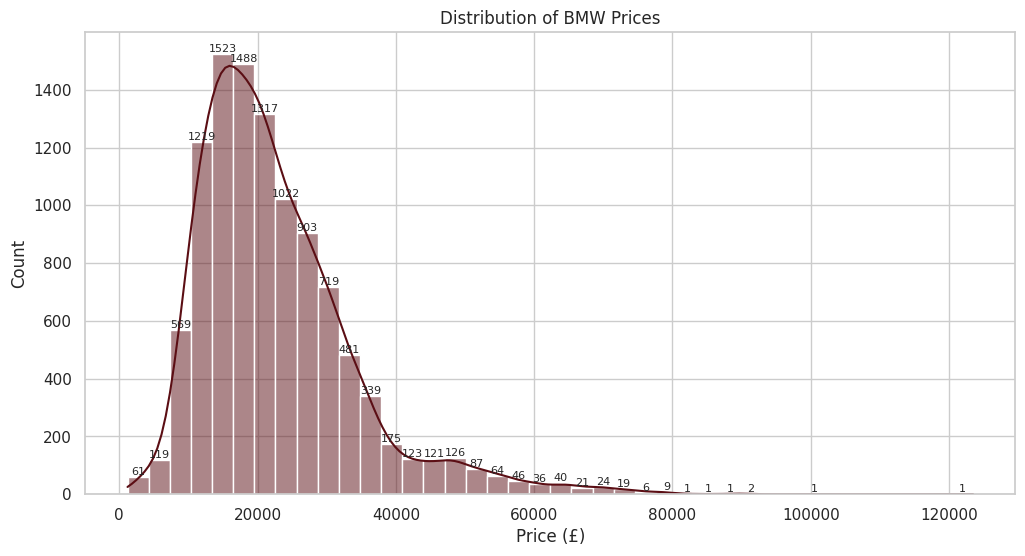

In [ ]:
#Distribution of car prices
plt.figure(figsize=(12, 6))

ax = sns.histplot(df['price'], bins=40, kde=True,color='#5B0E14')
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=8)

plt.title('Distribution of BMW Prices')
plt.xlabel('Price (£)')
plt.savefig('3_hist_price.png')

In [ ]:
import plotly.express as px

# Create interactive histogram
fig = px.histogram(
    df,
    x='price',
    nbins=40,
    color_discrete_sequence=['#5B0E14'], # Your custom dark red color
    title='Distribution of BMW Prices',
    labels={'price': 'Price (£)', 'count': 'Number of Cars'},
    text_auto=True,                      # REPLACES YOUR FOR LOOP: adds count labels automatically
    template='plotly_white',
    opacity=0.8
)

# Improve layout
fig.update_layout(
    bargap=0.05,                         # Small gap between bars for better look
    xaxis_title="Price (£)",
    yaxis_title="Count",
    title_x=0.5                          # Centers the title
)

# Optional: Add a box plot on top to see outliers
# fig.update_layout(marginal="box")

fig.show()

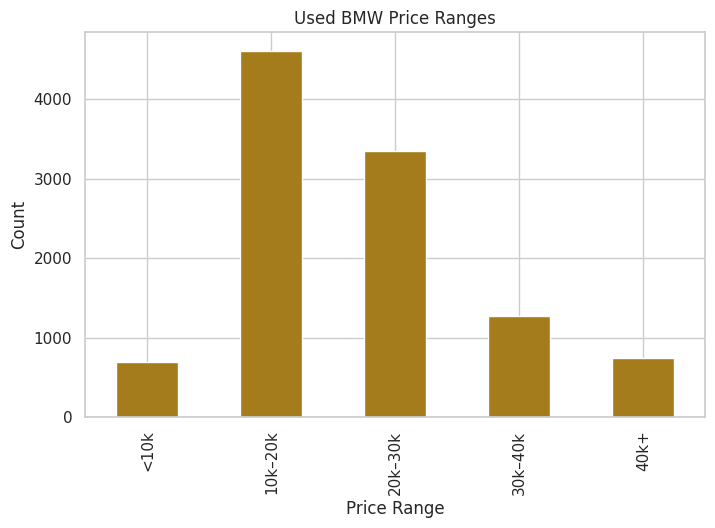

In [ ]:
price_bins = [0, 10000, 20000, 30000, 40000, 100000]
labels = ['<10k','10k–20k','20k–30k','30k–40k','40k+']

df['price_range'] = pd.cut(df['price'], bins=price_bins, labels=labels)

plt.figure(figsize=(8,5))

df['price_range'].value_counts().sort_index().plot(kind='bar',color='#a57c1b')

plt.title("Used BMW Price Ranges")
plt.xlabel("Price Range")
plt.ylabel("Count")

plt.show()


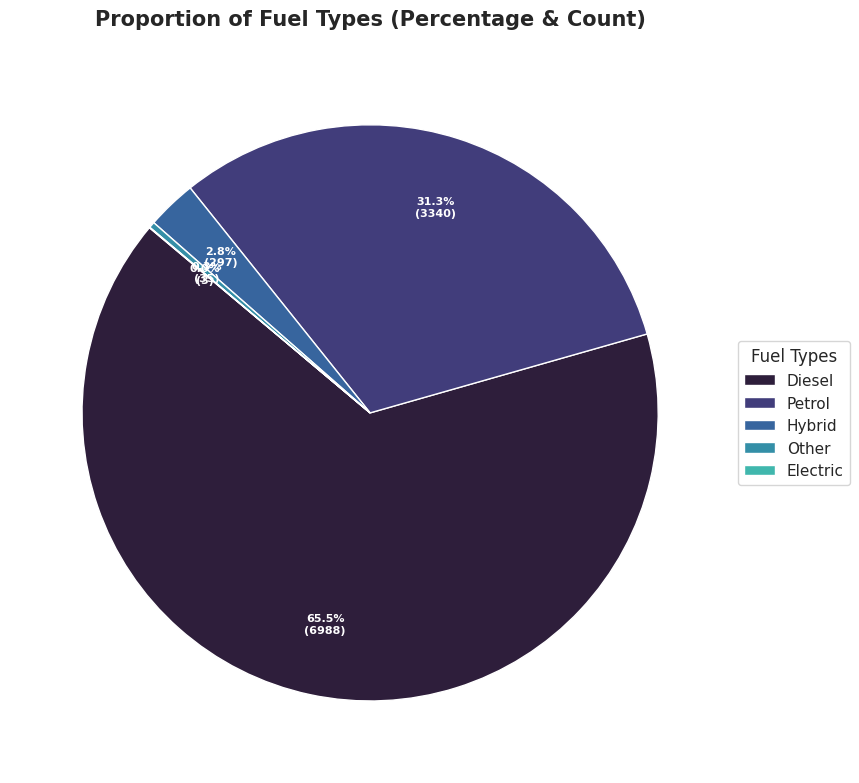

In [ ]:
counts = df['fueltype'].value_counts()
plt.figure(figsize=(10, 8))

colors = sns.color_palette('mako')[0:len(counts)]

wedges, texts, autotexts = plt.pie(
    counts,
    labels=None,          # Avoid overlapping labels
    autopct=lambda p: f'{p:.1f}%\n({int(p*sum(counts)/100)})',
    startangle=140,
    colors=colors,
    pctdistance=0.75,
    textprops={'fontsize':8, 'fontweight': 'bold', 'color':'white'}
)

plt.legend(
    wedges,
    counts.index,
    title="Fuel Types",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.title('Proportion of Fuel Types (Percentage & Count)', fontsize=15, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('v4_pie_fuel_type_fixed.png')
plt.show()

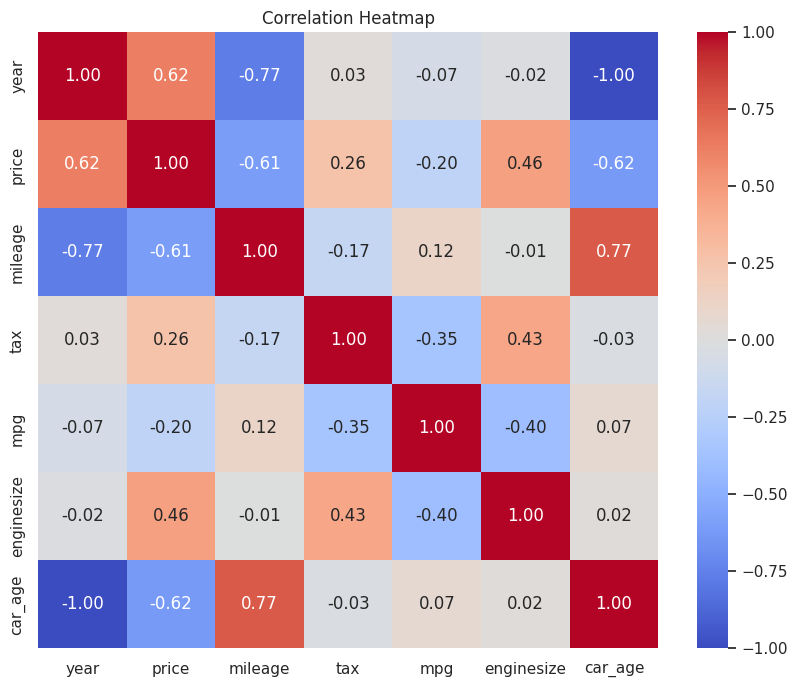

In [ ]:
# Correlation between numerical features
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.savefig('5_heatmap_corr.png')

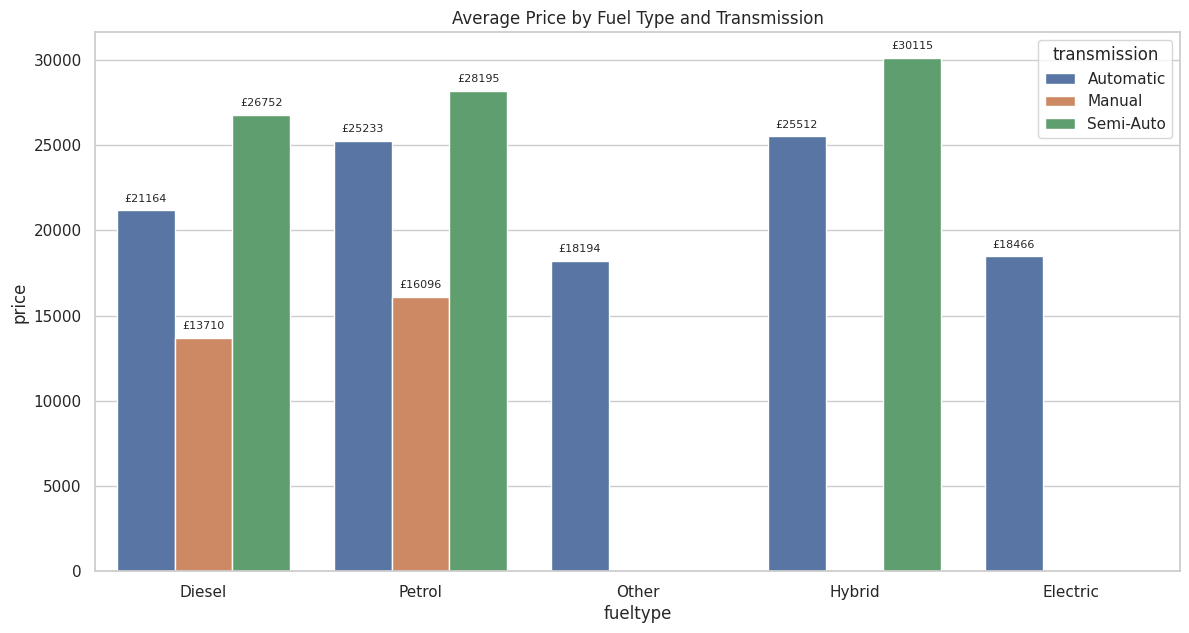

In [ ]:
plt.figure(figsize=(14, 7))
ax = sns.barplot(x='fueltype', y='price', hue='transmission', data=df, errorbar=None)
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'£{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontsize=8)
plt.title('Average Price by Fuel Type and Transmission')
plt.savefig('v6_cluster_bar_trans_fuel.png')

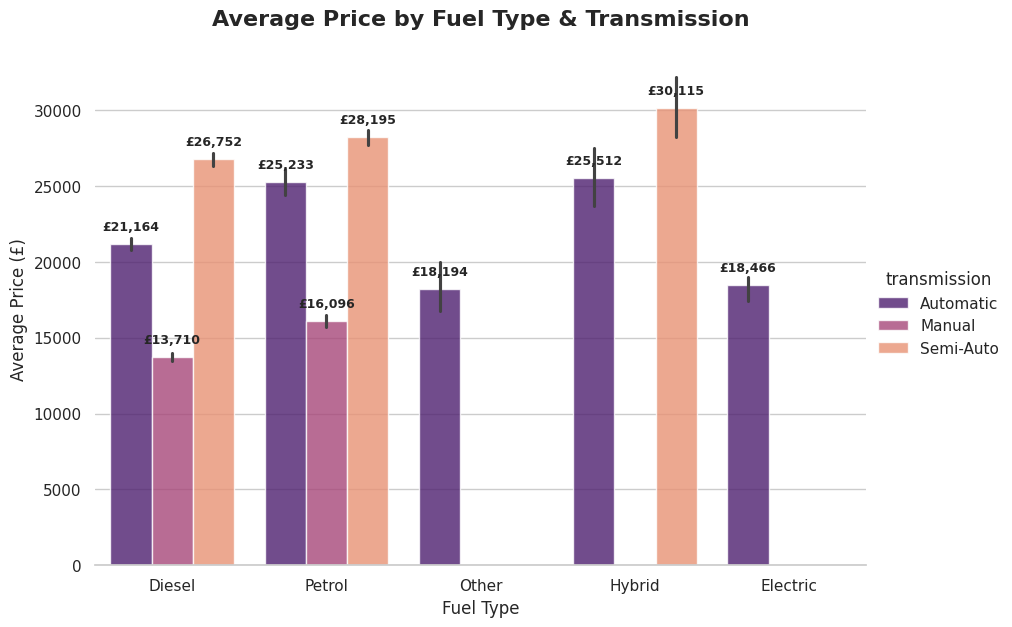

In [ ]:
df.columns = df.columns.str.strip().str.lower()
df['fueltype'] = df['fueltype'].str.strip()
df['transmission'] = df['transmission'].str.strip()
g = sns.catplot(
    data=df,
    kind="bar",
    x="fueltype",
    y="price",
    hue="transmission",
    palette="magma",
    alpha=.8,
    height=6,
    aspect=1.5
)
for ax in g.axes.flat:
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'£{p.get_height():,.0f}',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='bottom',
                        xytext=(0, 8),
                        textcoords='offset points',
                        fontsize=9,
                        fontweight='bold')

g.despine(left=True)
g.set_axis_labels("Fuel Type", "Average Price (£)")
plt.title("Average Price by Fuel Type & Transmission", fontsize=16, fontweight='bold', pad=20)

plt.savefig('catplot_price_analysis.png')
plt.show()

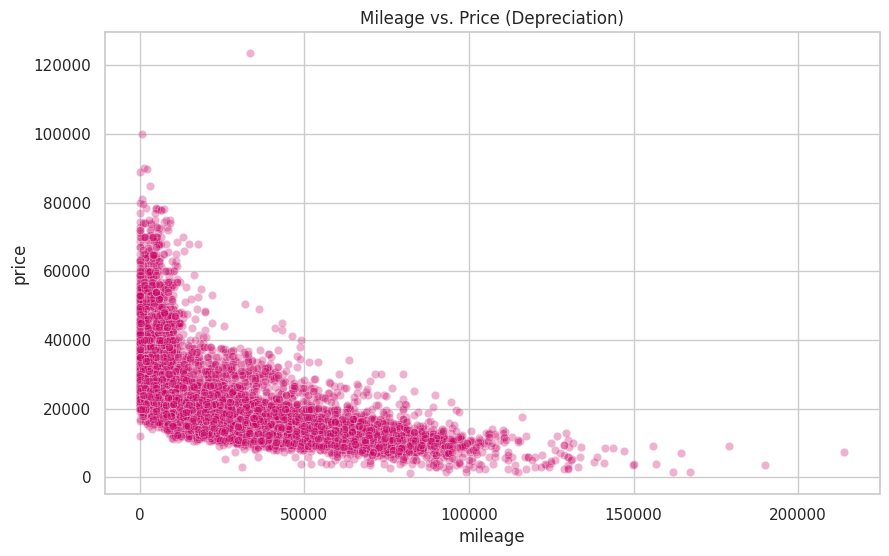

In [ ]:
# Mileage vs. Price (Depreciation)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='mileage', y='price', data=df, alpha=0.3, color='#c80064')
plt.title('Mileage vs. Price (Depreciation)')
plt.savefig('7_scatter_mileage_price.png')

Text(0.5, 1.0, 'Price Distribution by Fuel Type')

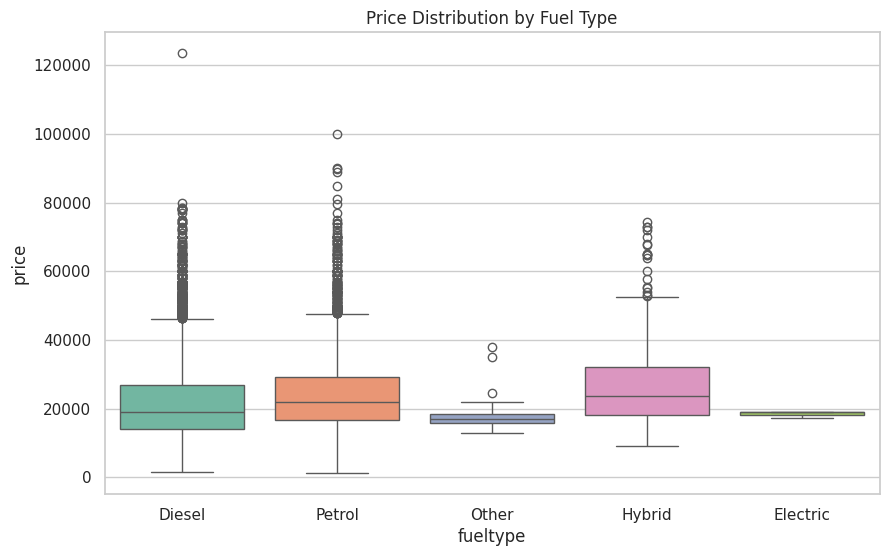

In [ ]:

plt.figure(figsize=(10, 6))
sns.boxplot(x='fueltype', y='price', data=df, palette='Set2')
plt.title('Price Distribution by Fuel Type')

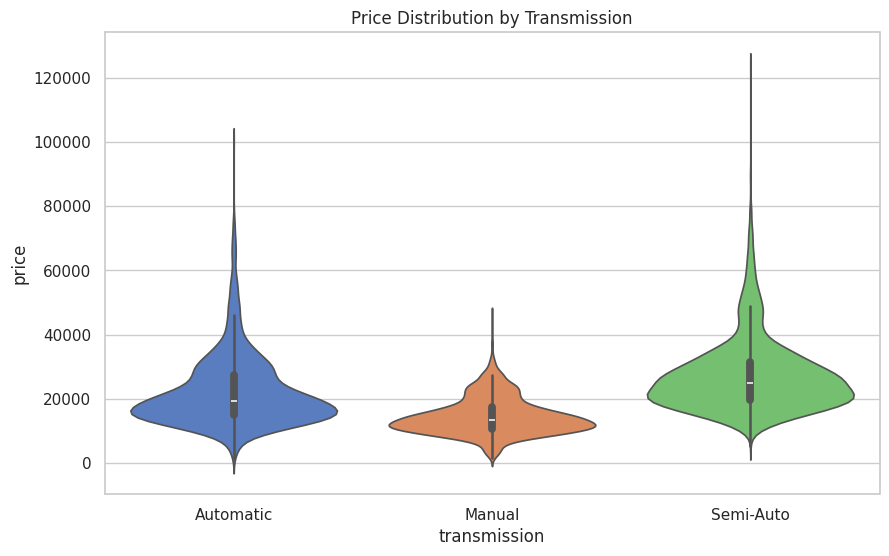

In [ ]:
# Price distribution by transmission
plt.figure(figsize=(10, 6))
sns.violinplot(x='transmission', y='price', data=df, palette='muted')
plt.title('Price Distribution by Transmission')
plt.savefig('9_violin_price_trans.png')

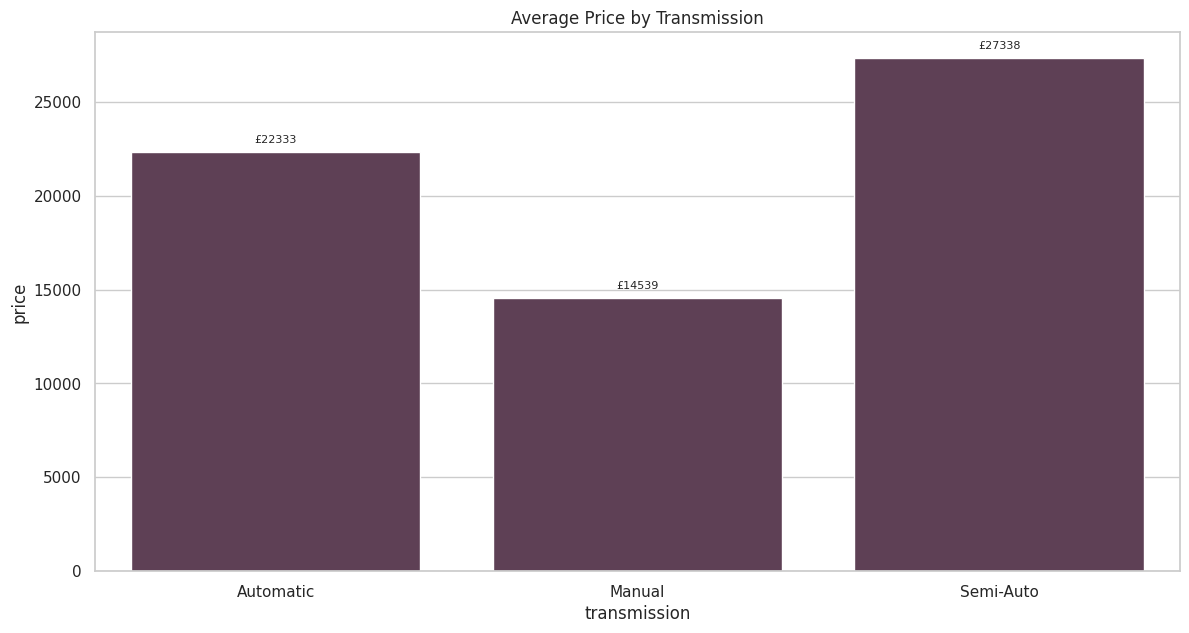

In [ ]:
plt.figure(figsize=(14, 7))
ax = sns.barplot(x='transmission', y='price', data=df,color='#633b57', errorbar=None)
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'£{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontsize=8)
plt.title('Average Price by Transmission')
plt.savefig('v6_cluster_bar_trans_fuel.png')

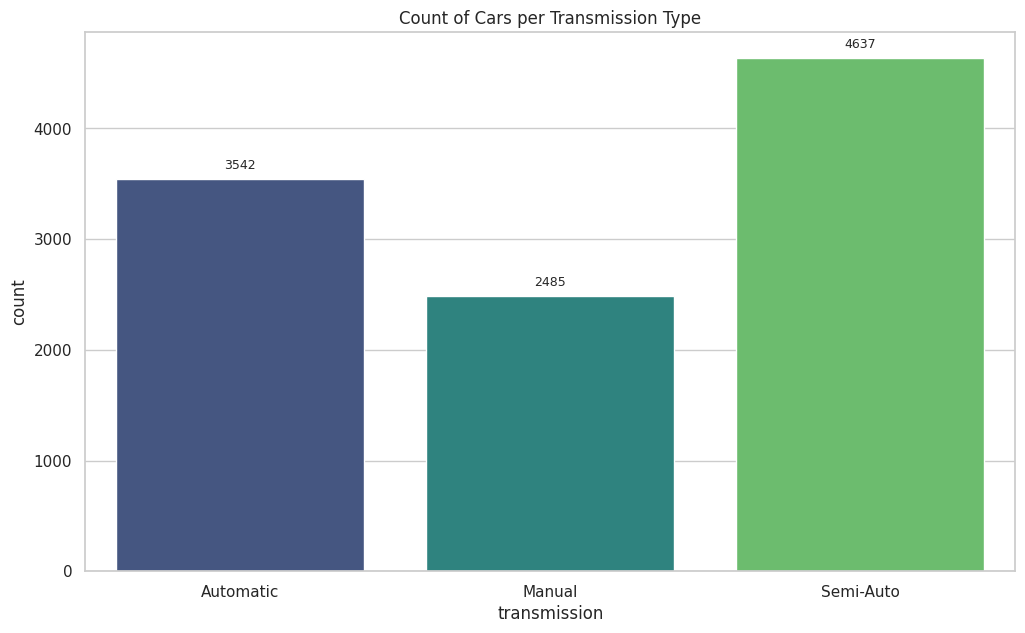

In [ ]:
#Count Plot: Transmission (with Counts)
plt.figure(figsize=(12, 7))
ax = sns.countplot(x='transmission', data=df, palette='viridis')
add_value_labels(ax)
plt.title('Count of Cars per Transmission Type')
plt.savefig('v10_count_transmission.png')




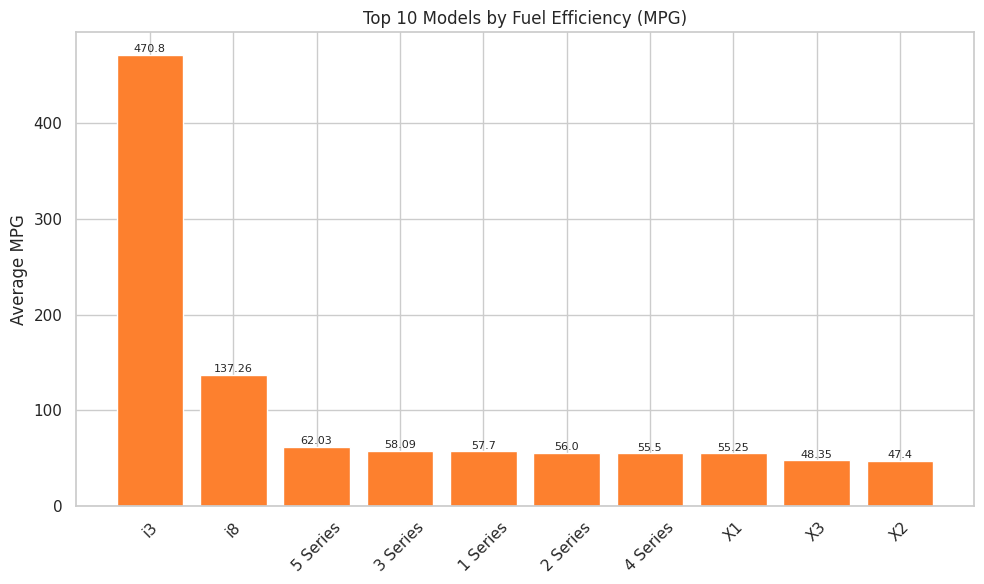

In [ ]:

top_10 = df.groupby('model')['mpg'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
bars = plt.bar(top_10.index, top_10.values, color='#FD802E')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, round(yval, 2),
             ha='center', va='bottom', fontsize=8)

plt.title('Top 10 Models by Fuel Efficiency (MPG)')
plt.ylabel('Average MPG')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('11_bar_mpg_model.png')
plt.show()


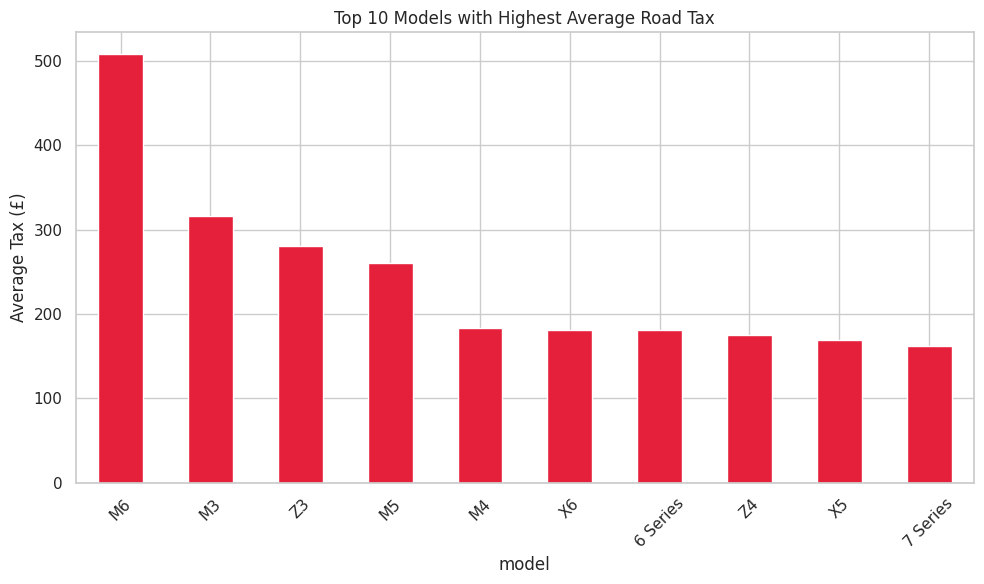

In [ ]:
# Top 10 Models with Highest Average Road Tax
plt.figure(figsize=(10, 6))
df.groupby('model')['tax'].mean().sort_values(ascending=False).head(10).plot(kind='bar', color='#E5203A')
plt.title('Top 10 Models with Highest Average Road Tax')
plt.ylabel('Average Tax (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('13_bar_tax_model.png')

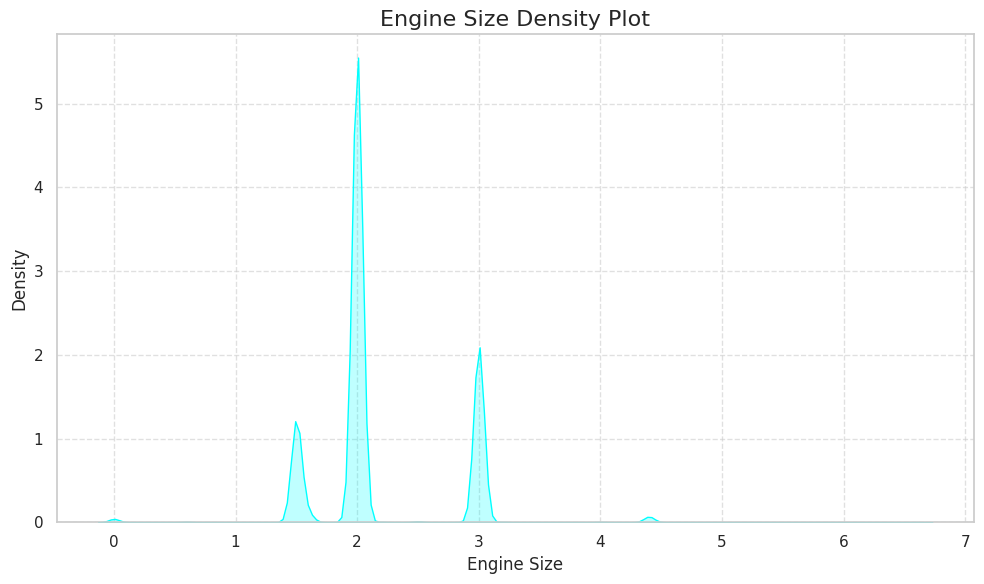

In [ ]:
df.columns = df.columns.str.strip().str.lower()

df['enginesize'] = pd.to_numeric(df['enginesize'], errors='coerce')

plt.figure(figsize=(10, 6))
sns.kdeplot(df['enginesize'], fill=True, color='cyan', bw_adjust=0.5)

plt.title('Engine Size Density Plot', fontsize=16)
plt.xlabel('Engine Size', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('v14_kde_engine_size_fixed.png')
plt.show()

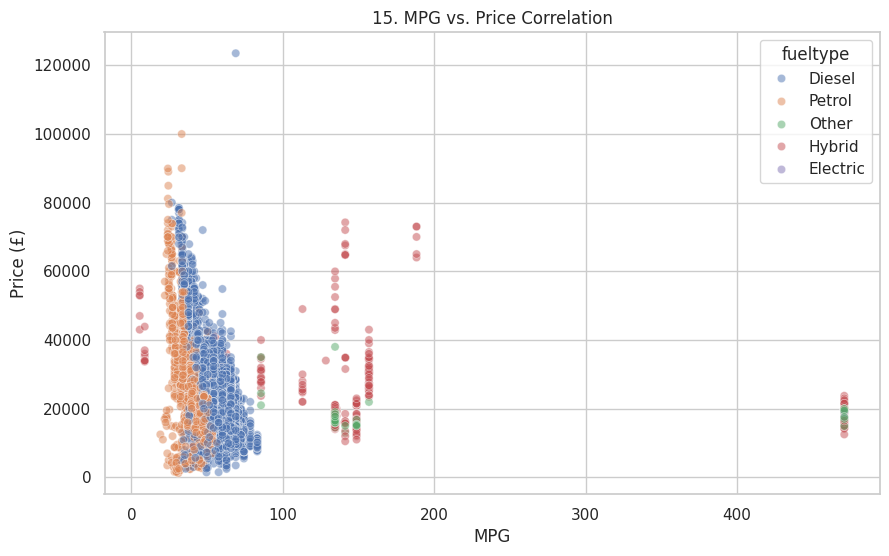

In [ ]:
# 15. Scatter Plot: MPG vs Price (colored by Fuel Type)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='mpg', y='price', data=df, hue='fueltype', alpha=0.5)
plt.title('15. MPG vs. Price Correlation')
plt.xlabel('MPG')
plt.ylabel('Price (£)')
plt.savefig('15_scatter_mpg_price.png')

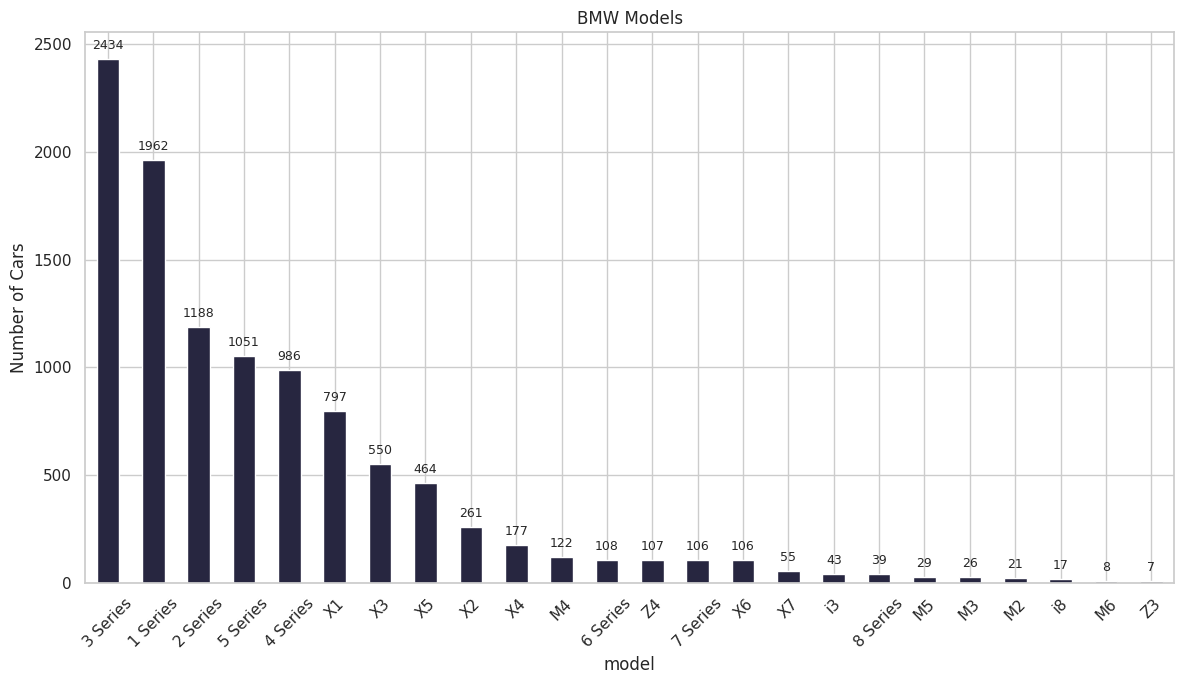

In [ ]:
plt.figure(figsize=(12, 7))
ax = df['model'].value_counts().plot(kind='bar', color='#272640')
add_value_labels(ax)
plt.title('BMW Models')
plt.ylabel('Number of Cars')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('v1_bar_top_models.png')





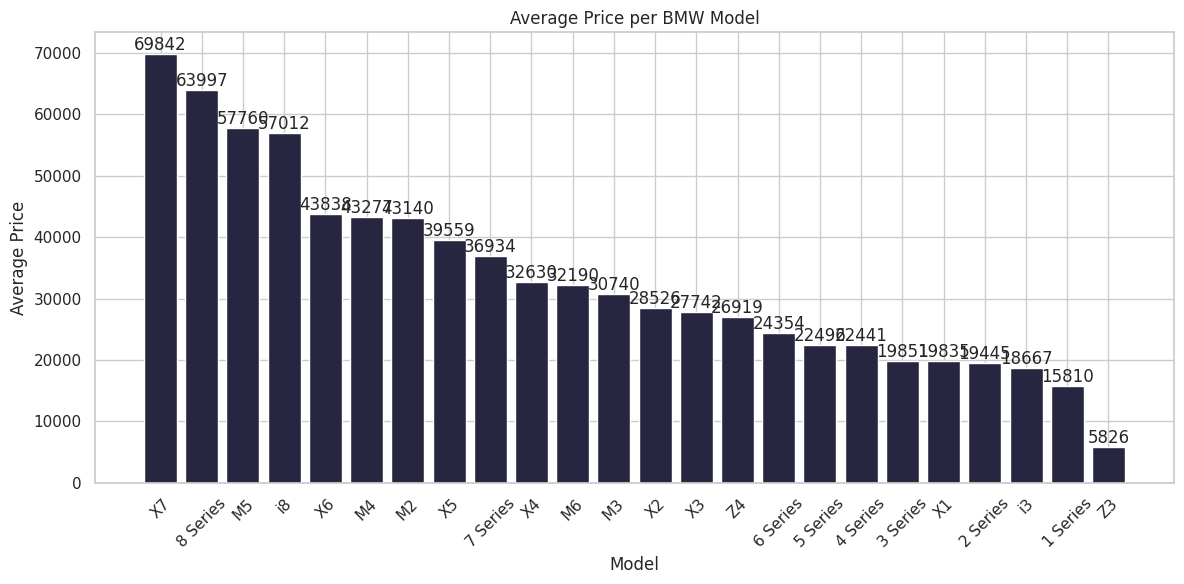

In [ ]:

# Calculate average price per model
avg_price_model = df.groupby('model')['price'].mean().sort_values(ascending=False)
# Plot bar chart
plt.figure(figsize=(12,6))
bars = plt.bar(avg_price_model.index, avg_price_model.values,color='#272640')

plt.title('Average Price per BMW Model')
plt.xlabel('Model')
plt.ylabel('Average Price')
plt.xticks(rotation=45)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


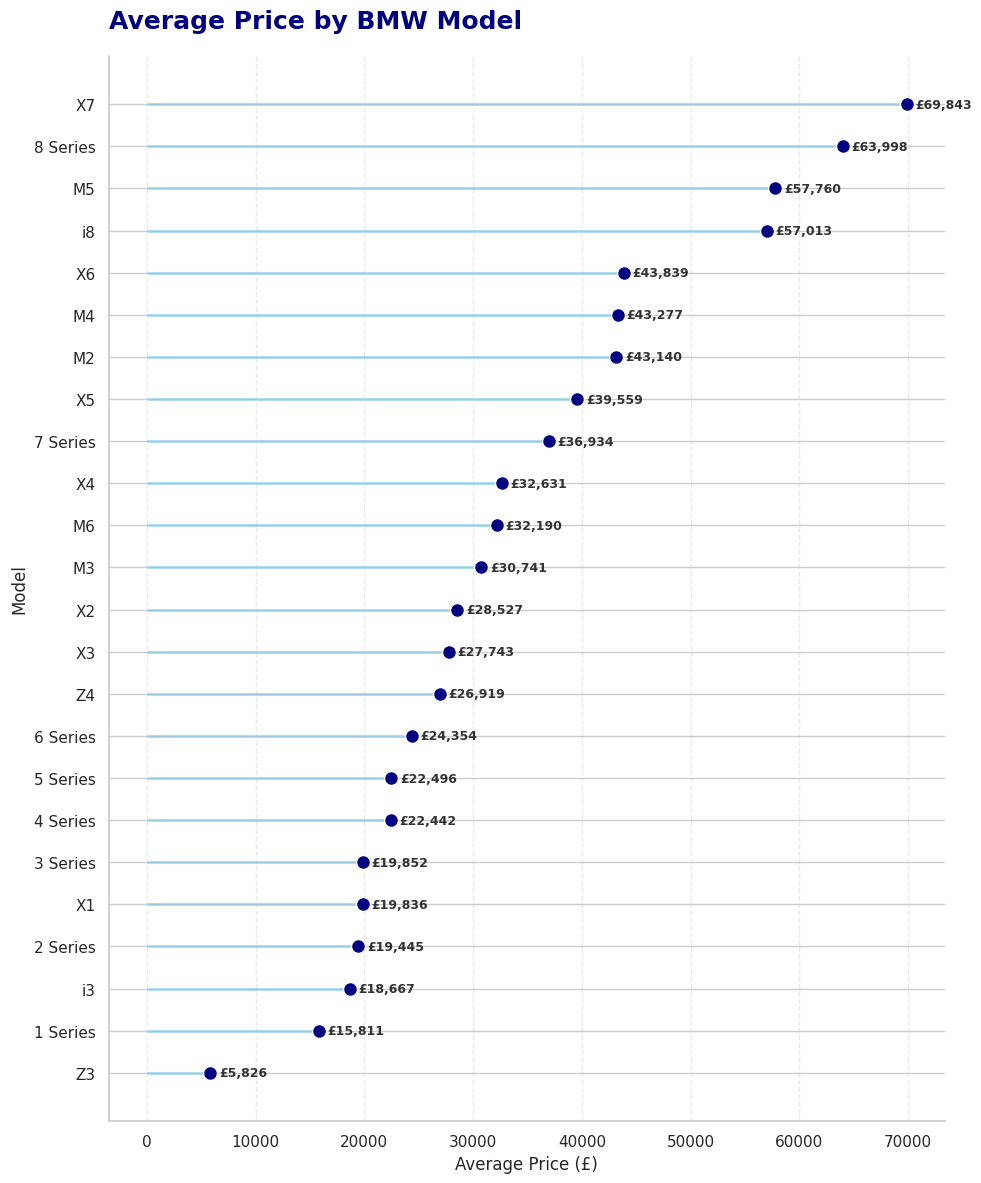

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Clean and Prepare Data
# df = pd.read_csv('bmw.csv')
df['model'] = df['model'].str.strip()
stats = df.groupby('model')['price'].mean().sort_values(ascending=True)

# 2. Create the Plot
plt.figure(figsize=(10, 12))

# Draw the "Sticks" (Horizontal lines)
plt.hlines(y=stats.index, xmin=0, xmax=stats.values, color='skyblue', alpha=0.7, linewidth=2)

# Draw the "Lollipops" (Markers)
plt.scatter(stats.values, stats.index, color='navy', s=100, alpha=1, edgecolors='white', zorder=3)

# 3. Add Value Labels
for i, v in enumerate(stats.values):
    plt.text(v + 800, i, f'£{v:,.0f}', va='center', fontsize=9, fontweight='bold', color='#333333')

# 4. Styling
plt.title('Average Price by BMW Model', loc='left', fontsize=18, fontweight='bold', color='navy', pad=20)
plt.xlabel('Average Price (£)', fontsize=12)
plt.ylabel('Model', fontsize=12)

# Add a light vertical grid to help trace values
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('lollipop_price_model.png')
plt.show()

In [ ]:

# 1. Prepare Data
df.columns = df.columns.str.strip().str.lower()
df['model'] = df['model'].str.strip()

# Calculate Average Price
stats = df.groupby('model')['price'].mean().sort_values(ascending=False).reset_index()
models = stats['model'].tolist()

# 2. Create ColumnDataSource (The Bokeh way of handling data)
source = ColumnDataSource(stats)

# 3. Create the Figure
p = figure(x_range=models, height=500, width=1000, title="Average Price by BMW Model (Interactive)",
           toolbar_location="above", tools="pan,wheel_zoom,box_zoom,reset")

# 4. Add Bar Glyph
p.vbar(x='model', top='price', width=0.8, source=source,
       line_color='white',
       fill_color=factor_cmap('model', palette=Viridis256[:len(models)], factors=models))

# 5. Add the "Correction": HoverTool
# This allows the user to see exact values without cluttering the chart
hover = HoverTool()
hover.tooltips = [
    ("Model", "@model"),
    ("Avg Price", "£@price{0,0}")
]
p.add_tools(hover)

# 6. Styling
p.xgrid.grid_line_color = None
p.xaxis.major_label_orientation = 1.2  # Rotate labels
p.yaxis.formatter = NumeralTickFormatter(format="£0,0") # Format Y axis as currency
p.title.text_font_size = '16pt'

# 7. Output
output_file("interactive_bmw_prices.html")
save(p)
# show(p) # Use show(p) if running in a Jupyter Notebook/Colab

'/content/interactive_bmw_prices.html'

<Figure size 1000x600 with 0 Axes>

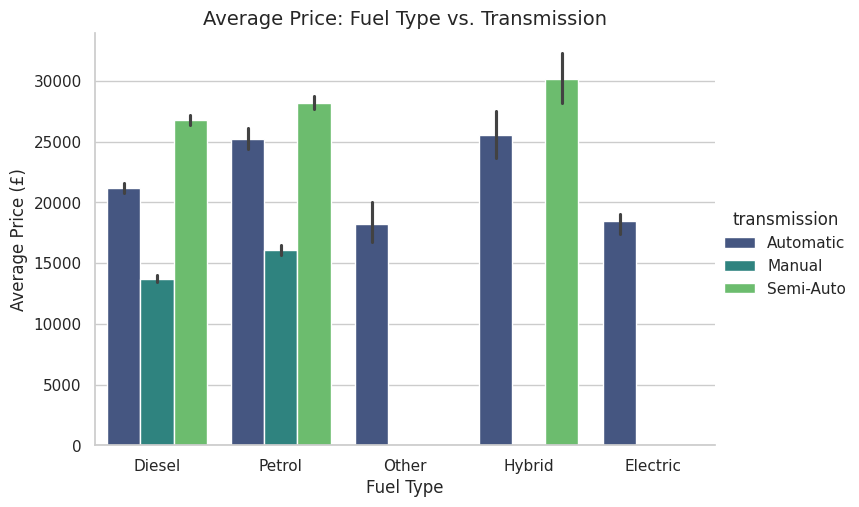

In [ ]:
# Using catplot to see complex relationships
plt.figure(figsize=(10,6))
g = sns.catplot(data=df, x='fueltype', y='price', hue='transmission',
                kind='bar', palette='viridis', height=5, aspect=1.5)

plt.title('Average Price: Fuel Type vs. Transmission', fontsize=14)
plt.ylabel('Average Price (£)')
plt.xlabel('Fuel Type')
plt.show()

In [ ]:
!pip install joypy

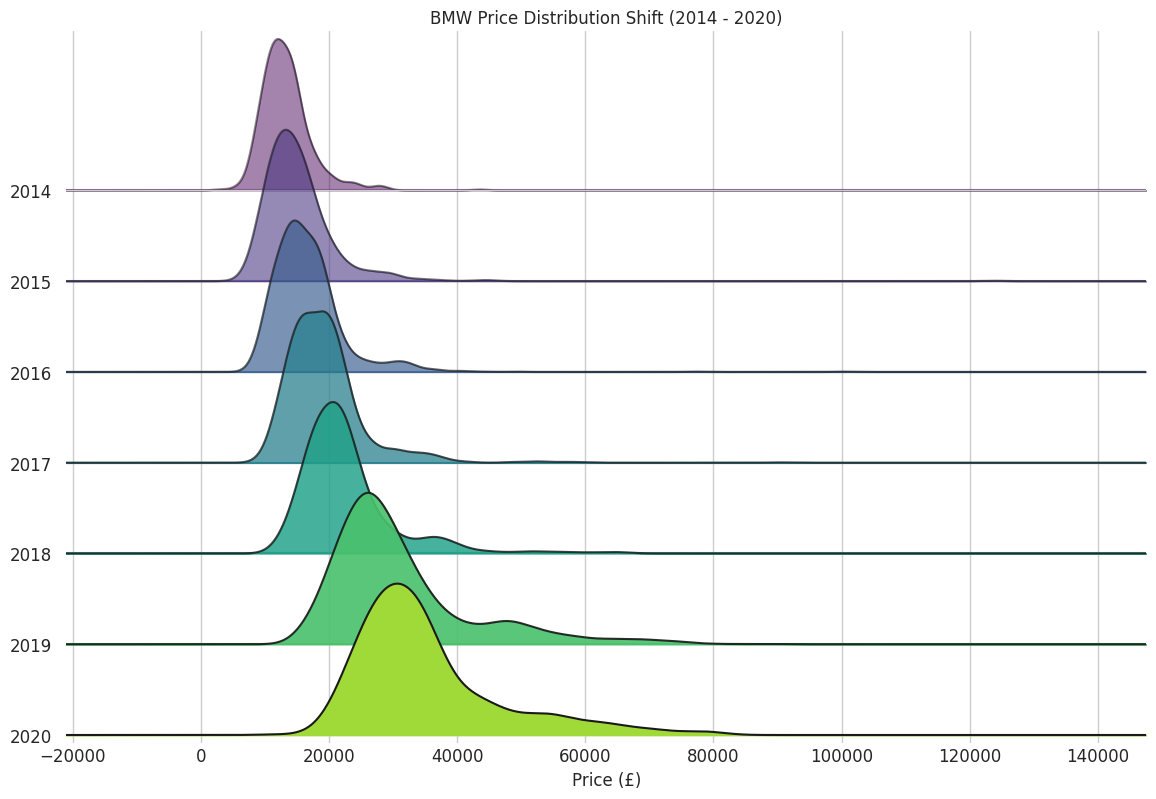

In [ ]:

import joypy
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm

# 1. Clean and filter the data
df['year'] = df['year'].astype(int)
# Filtering for a specific range makes the plot more readable
df_filtered = df[df['year'].between(2014, 2020)].sort_values('year')

# 2. Create the Joyplot
fig, axes = joypy.joyplot(
    data=df_filtered,
    column='price',
    by='year',
    ylim='own',
    colormap=cm.viridis,
    fade=True,
    grid=True,
    labels=None, # Set to None if you want custom labels or keep for years
    title="BMW Price Distribution Shift (2014 - 2020)",
    kind="kde",
    figsize=(12, 8)
)

plt.xlabel("Price (£)")
plt.savefig('joypy_price_by_year.png')
plt.show()